In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('IMDB_10000.csv')  

df.head()

,title,year,certificate,runtime,genre,desc,rating,votes
0,Freddy,2022,UA 16+,124 min,"Drama, Mystery, Thriller",The lines between love and obsession blur in t...,7.9,"16,441"
1,An Action Hero,2022,U,130 min,Action,Youth Icon. Superstar. Action Hero. At the age...,8.1,"15,690"
2,Kantara,2022,UA,148 min,"Action, Adventure, Drama",It involves culture of Kambala and Bhootha Kol...,8.7,"78,358"
3,Khakee: The Bihar Chapter,2022–,UA 13+,45 min,"Action, Crime, Drama",As a righteous cop pursues a merciless crimina...,8.3,"4,464"
4,Drishyam 2,2022,UA,140 min,"Crime, Drama, Mystery",A gripping tale of an investigation and a fami...,8.6,"18,743"


In [3]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')


df['year'] = df['year'].fillna(0).astype(int)  
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['votes'] = df['votes'].fillna(0)


df['genre'] = df['genre'].astype('category')

In [4]:
df

,title,year,certificate,runtime,genre,desc,rating,votes
0,Freddy,2022,UA 16+,124 min,"Drama, Mystery, Thriller",The lines between love and obsession blur in t...,7.900000,0.0
1,An Action Hero,2022,U,130 min,Action,Youth Icon. Superstar. Action Hero. At the age...,8.100000,0.0
2,Kantara,2022,UA,148 min,"Action, Adventure, Drama",It involves culture of Kambala and Bhootha Kol...,8.700000,0.0
3,Khakee: The Bihar Chapter,0,UA 13+,45 min,"Action, Crime, Drama",As a righteous cop pursues a merciless crimina...,8.300000,0.0
4,Drishyam 2,2022,UA,140 min,"Crime, Drama, Mystery",A gripping tale of an investigation and a fami...,8.600000,0.0
...,...,...,...,...,...,...,...,...
9995,Kisan Aur Bhagwan,1974,NaN,142 min,"Action, Comedy, Drama",NaN,6.568267,0.0
9996,Aadmi Sadak Ka,1977,NaN,138 min,"Drama, Family",NaN,6.568267,0.0
9997,Nadodi Mannan,1958,NaN,220 min,"Action, Adventure, Comedy",NaN,6.568267,0.0
9998,Njan Marykutty,2018,U,126 min,Drama,NaN,6.568267,0.0


genre
Animation, Drama, Romance                       9.80
Drama, Comedy, Family                           9.40
Documentary, Reality-TV, Romance                9.25
Biography, Crime, Thriller                      9.20
Western                                         9.10
                                                ... 
Short, Comedy, Fantasy                          3.90
Crime, Fantasy, Romance                         3.75
Drama, Family, Horror                           3.70
Action, Reality-TV                              3.40
Short, Drama, Fantasy                           2.80
Name: rating, Length: 491, dtype: float64


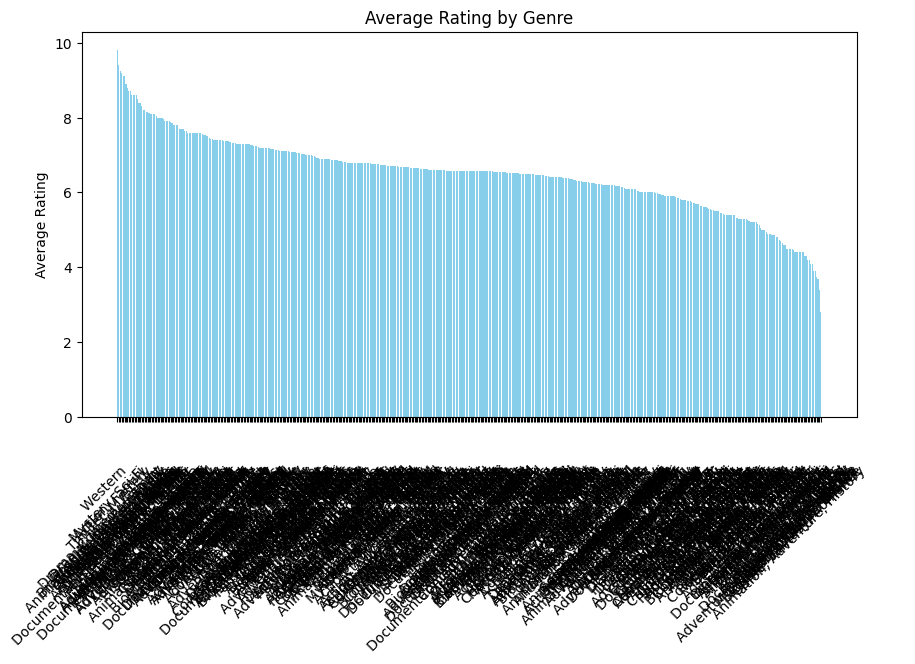

In [5]:
genre_rating = df.groupby('genre')['rating'].mean().sort_values(ascending=False)
print(genre_rating)


plt.figure(figsize=(10,5))
plt.bar(genre_rating.index, genre_rating.values, color='skyblue')
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.title("Average Rating by Genre")
plt.show()

Correlation between Votes and Rating: -0.14172644090766734


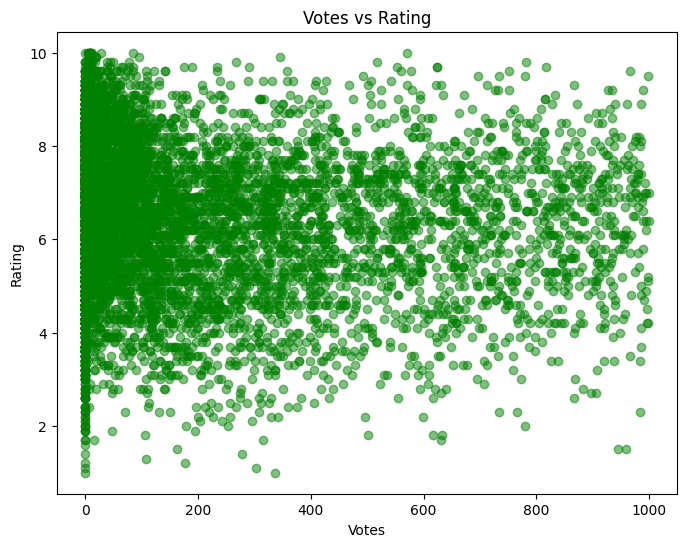

In [6]:
corr = df['votes'].corr(df['rating'])
print("Correlation between Votes and Rating:", corr)

plt.figure(figsize=(8,6))
plt.scatter(df['votes'], df['rating'], alpha=0.5, color='green')
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")
plt.show()

In [7]:
top_voted = df.sort_values(by='votes', ascending=False).head(10)
top_voted[['title', 'votes', 'rating']]

,title,votes,rating
3510,Banni Chow Home Delivery,999.0,6.4
5306,Padayappa,999.0,7.0
7929,Muthal Mariyathai,998.0,9.5
401,Raat Akeli Hai,998.0,4.2
3222,Medium Spicy,998.0,5.2
5761,Jay Jay,997.0,5.1
851,Johnny Gaddaar,996.0,4.5
2435,Jailer,996.0,4.2
6870,Dil Jo Bhi Kahey...,995.0,4.9
2458,Baaghi: A Rebel for Love,995.0,6.2


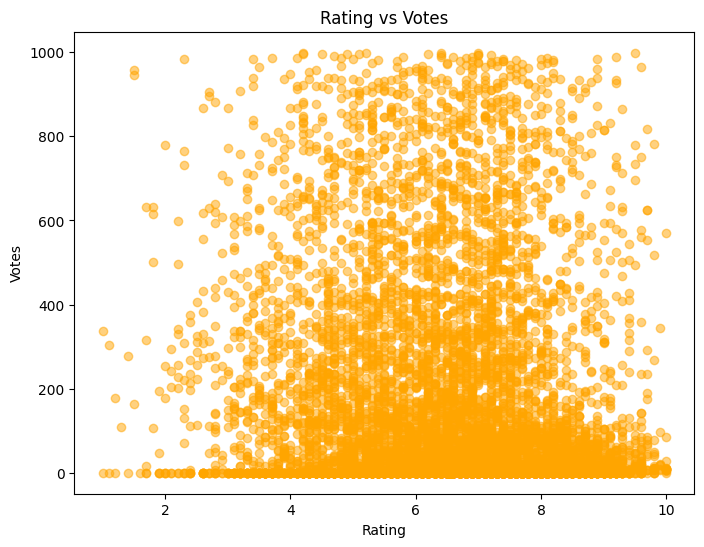

Correlation between Rating and Votes: -0.1417264409076673


In [8]:
plt.figure(figsize=(8,6))
plt.scatter(df['rating'], df['votes'], alpha=0.5, color='orange')
plt.xlabel("Rating")
plt.ylabel("Votes")
plt.title("Rating vs Votes")
plt.show()

rating_corr = df['rating'].corr(df['votes'])
print("Correlation between Rating and Votes:", rating_corr)

year
0       2263
1913       1
1923       1
1929       1
1932       2
        ... 
2020     282
2021     546
2022    1036
2023     116
2024       5
Name: title, Length: 87, dtype: int64


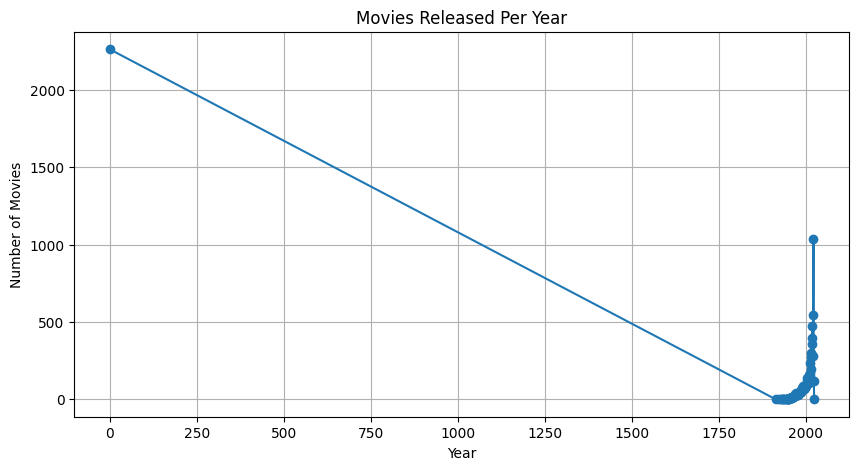

In [9]:
movies_per_year = df.groupby('year')['title'].count()
print(movies_per_year)

plt.figure(figsize=(10,5))
plt.plot(movies_per_year.index, movies_per_year.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.title("Movies Released Per Year")
plt.grid(True)
plt.show()

In [10]:
genre_year = df.groupby(['year', 'genre'])['title'].count().unstack().fillna(0)


growth = genre_year.diff().iloc[-1]
print("Growth in number of releases by genre last year:")
print(growth.sort_values(ascending=False))

Growth in number of releases by genre last year:
genre
Animation, Action, Adventure                 1.0
Drama, Music                                 0.0
Drama, Horror, Romance                       0.0
Drama, Horror, Mystery                       0.0
Drama, Horror, Musical                       0.0
                                            ... 
Action, Thriller                            -6.0
Action                                      -7.0
Action, Drama, Thriller                     -8.0
Action, Drama                              -11.0
Drama                                      -12.0
Name: 2024, Length: 491, dtype: float64
